<h1 align="center">Predictive Analysis</h1>

## Importing nesessary libraries & Load the dataset

In [ ]:
# Importing nesessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
demo = pd.read_csv("data/cleaned/Cleaned_demographics.csv")

## 1. DYNAMIC CARB-TO-INSULIN RATIO (CIR) PREDICTION


# Hypotheses:
CIR is not constant and varies based on physiological and behavioral factors such as activity level, heart rate/stress, glucose trends, and time of day.

# Markers:
- Physical activity level
- Heart rate / stress proxy
- Glucose trend (slope & variability)
- Time of day (circadian influence)
- Carbohydrate intake
- Bolus insulin delivered

# Models:
- Regression model (e.g., Linear Regression / Gradient Boosting Regressor)




DYNAMIC CIR PREDICTION MODEL


MAE  : 2.60
RMSE : 7.86
R²   : 0.152


/var/folders/yh/fqj3f0l57lz4sc88lswwcxvm0000gn/T/ipykernel_52743/587915901.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


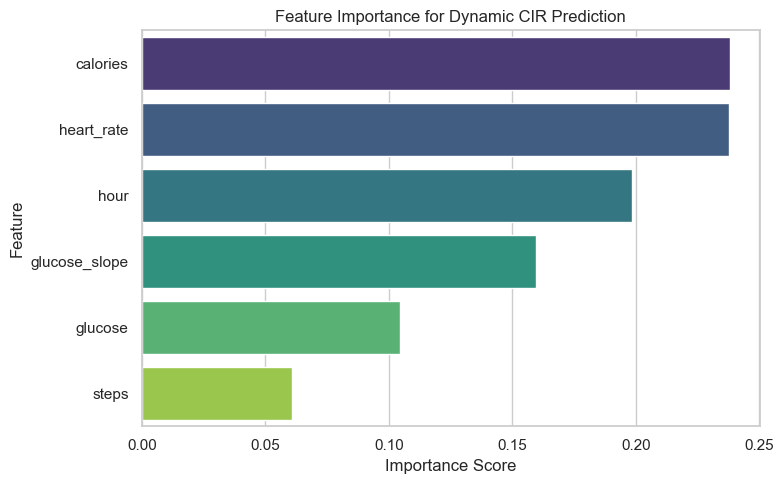

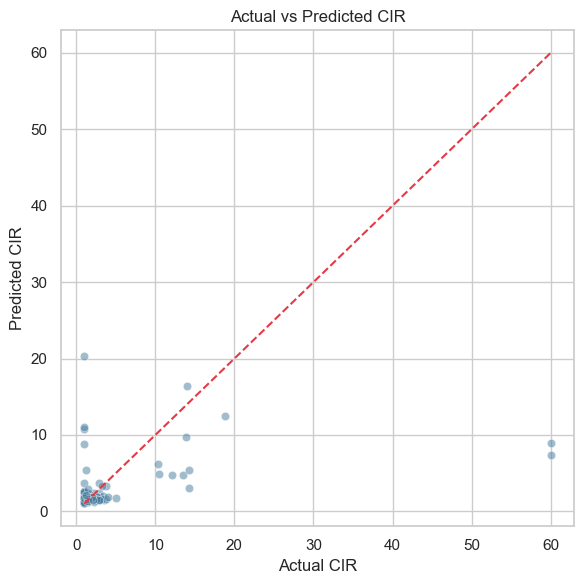

/var/folders/yh/fqj3f0l57lz4sc88lswwcxvm0000gn/T/ipykernel_52743/587915901.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


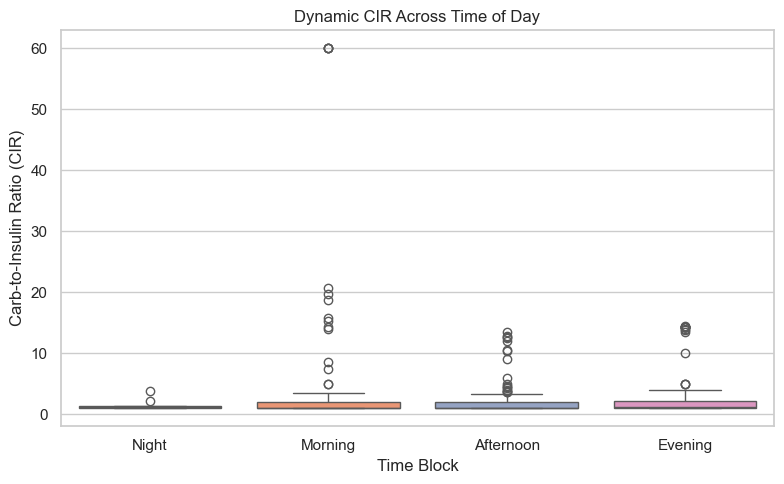

/var/folders/yh/fqj3f0l57lz4sc88lswwcxvm0000gn/T/ipykernel_52743/587915901.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


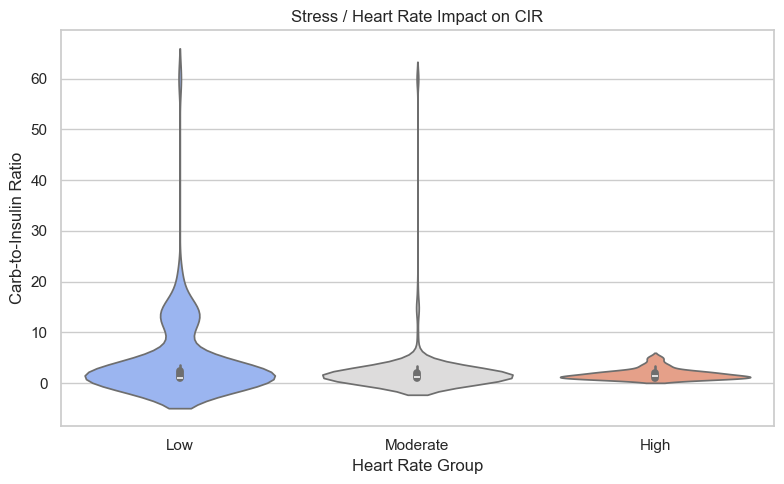


KEY INSIGHT

The model suggests that CIR is dynamic and changes based on physiological state, activity, heart rate, and glucose trend.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
sns.set_theme(style="whitegrid")

# STEP 1: CLEAN DATA
df = df.copy()
df.columns = df.columns.str.strip()
df["time"] = pd.to_datetime(df["time"])

# STEP 2: KEEP VALID MEAL + INSULIN EVENTS
cir_df = df[
    (df["carb_input"] > 0) &
    (df["bolus_volume_delivered"] > 0)
].copy()

# STEP 3: CREATE TARGET VARIABLE (CIR)
cir_df["CIR"] = (
    cir_df["carb_input"] /
    cir_df["bolus_volume_delivered"]
)
cir_df = cir_df[
    cir_df["CIR"].between(1, 60)
]

# STEP 4: FEATURE ENGINEERING
cir_df["hour"] = cir_df["time"].dt.hour

cir_df["time_block"] = pd.cut(
    cir_df["hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    include_lowest=True
)

# Glucose Slope (trend)
cir_df = cir_df.sort_values(
    ["patient_id", "time"]
)

cir_df["glucose_slope"] = (
    cir_df.groupby("patient_id")["glucose"]
    .diff()
)

# Heart Rate Stress Group
cir_df["hr_group"] = pd.cut(
    cir_df["heart_rate"],
    bins=[0, 70, 100, 200],
    labels=["Low", "Moderate", "High"]
)

# STEP 5: SELECT FEATURES
features = [
    "glucose",
    "heart_rate",
    "steps",
    "calories",
    "glucose_slope",
    "hour"
]
model_df = cir_df[
    features + ["CIR"]
].dropna()

# STEP 6: TRAIN / TEST SPLIT
X = model_df[features]
y = model_df["CIR"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# STEP 7: TRAIN REGRESSION MODEL
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)

# STEP 8: PREDICTIONS
preds = model.predict(X_test)

# STEP 9: EVALUATION
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
print("\n")
print("DYNAMIC CIR PREDICTION MODEL")
print("\n")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

# STEP 10: FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})
importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

# VISUALIZATION 1: FEATURE IMPORTANCE
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Feature Importance for Dynamic CIR Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# VISUALIZATION 2: ACTUAL vs PREDICTED
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=preds,
    alpha=0.5,
    color="#457b9d"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="#e63946"
)
plt.title("Actual vs Predicted CIR")
plt.xlabel("Actual CIR")
plt.ylabel("Predicted CIR")
plt.tight_layout()
plt.show()


# VISUALIZATION 3: CIR BY TIME OF DAY
plt.figure(figsize=(8,5))
sns.boxplot(
    data=cir_df,
    x="time_block",
    y="CIR",
    palette="Set2"
)
plt.title("Dynamic CIR Across Time of Day")
plt.xlabel("Time Block")
plt.ylabel("Carb-to-Insulin Ratio (CIR)")
plt.tight_layout()
plt.show()


# VISUALIZATION 4:
# HEART RATE vs CIR
plt.figure(figsize=(8,5))
sns.violinplot(
    data=cir_df,
    x="hr_group",
    y="CIR",
    palette="coolwarm"
)

plt.title("Stress / Heart Rate Impact on CIR")
plt.xlabel("Heart Rate Group")
plt.ylabel("Carb-to-Insulin Ratio")
plt.tight_layout()
plt.show()

# SUMMARY INSIGHT
print("\n================================================")
print("KEY INSIGHT")
print("================================================\n")
print(
    "The model suggests that CIR is dynamic and "
    "changes based on physiological state, activity, "
    "heart rate, and glucose trend."
)


## 2. Carbohydrate Absorption Rate Prediction

# Hypotheses:
Carbohydrate absorption speed (fast, medium, slow) is influenced by post-meal glucose response patterns along with physiological signals like activity and heart rate.

# Markers:
- Post-meal glucose curve shape
- Glucose slope after meal
- Heart rate changes
- Activity level
- Carbohydrate quantity

# Models:
- Random Forest Classifier



CARBOHYDRATE ABSORPTION PREDICTION

Accuracy: 1.000

Classification Report:

              precision    recall  f1-score   support

        Fast       1.00      1.00      1.00       159
      Medium       1.00      1.00      1.00       156
        Slow       1.00      1.00      1.00       162

    accuracy                           1.00       477
   macro avg       1.00      1.00      1.00       477
weighted avg       1.00      1.00      1.00       477



/var/folders/yh/fqj3f0l57lz4sc88lswwcxvm0000gn/T/ipykernel_52743/3701829045.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


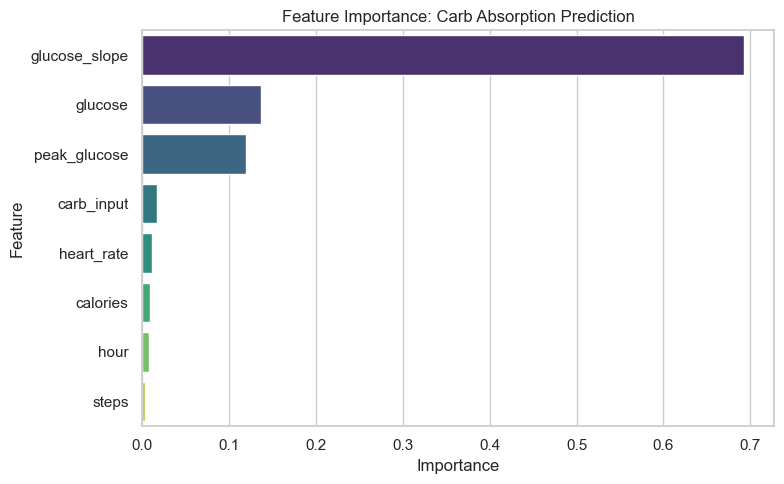

/var/folders/yh/fqj3f0l57lz4sc88lswwcxvm0000gn/T/ipykernel_52743/3701829045.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


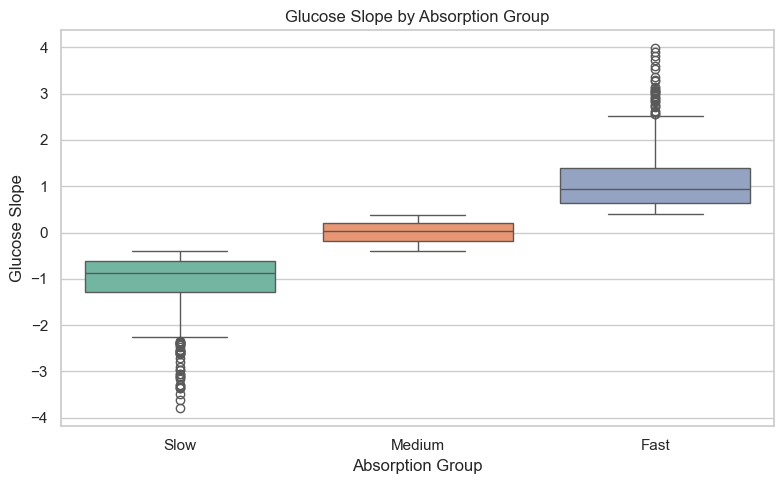

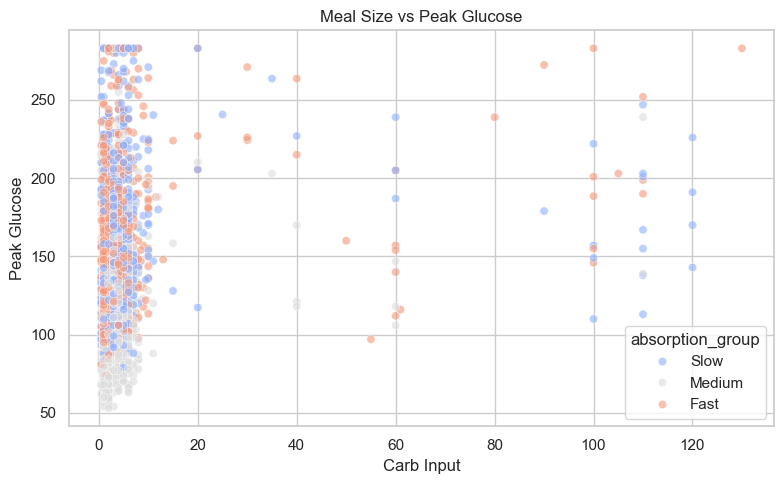

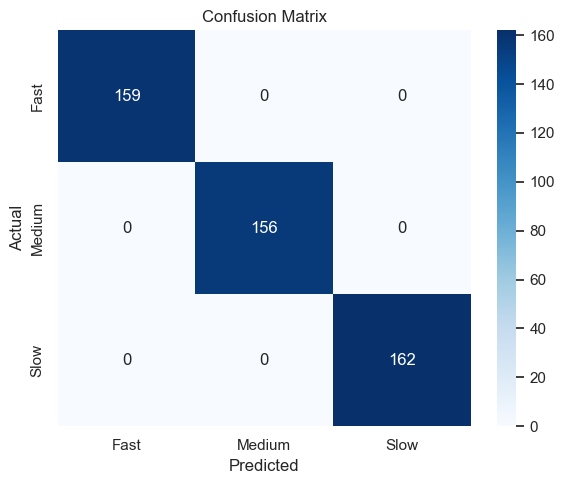

/var/folders/yh/fqj3f0l57lz4sc88lswwcxvm0000gn/T/ipykernel_52743/3701829045.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


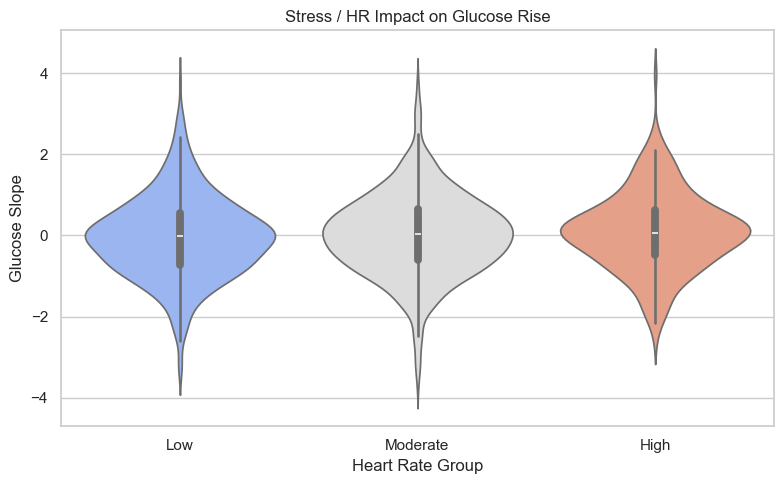


KEY INSIGHT

Post-meal glucose dynamics can be used to estimate carbohydrate absorption speed. Glucose slope, heart rate, and meal size were among the strongest predictors.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

sns.set_theme(style="whitegrid")

# STEP 1: PREPARE DATA
df = df.copy()
df.columns = df.columns.str.strip()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(
    ["patient_id", "time"]
)

# STEP 2: DETECT MEAL EVENTS
meal_df = df[
    (df["carb_input"] > 0) &
    (df["glucose"].notna())
].copy()

# STEP 3: CREATE POST-MEAL FEATURES
# Assuming CGM every 5 min:
# 12 rows ≈ 60 minutes
# Future glucose after 60 mins
meal_df["future_glucose"] = (
    meal_df.groupby("patient_id")["glucose"]
    .shift(-12)
)

# Remove missing future values
meal_df = meal_df.dropna(
    subset=["future_glucose"]
)

# GLUCOSE RESPONSE FEATURES
# glucose rise
meal_df["delta_glucose"] = (
    meal_df["future_glucose"] -
    meal_df["glucose"]
)

# glucose slope
meal_df["glucose_slope"] = (
    meal_df["delta_glucose"] / 60
)

# PEAK GLUCOSE ESTIMATION
meal_df["peak_glucose"] = (
    meal_df[["glucose", "future_glucose"]]
    .max(axis=1)
)

# CREATE ABSORPTION GROUPS
# Fast:steep glucose rise
# Medium:moderate rise
# Slow:minimal rise
meal_df["absorption_group"] = pd.qcut(
    meal_df["glucose_slope"],
    q=3,
    labels=["Slow", "Medium", "Fast"]
)

# STEP 4: FEATURE ENGINEERING
meal_df["hour"] = meal_df["time"].dt.hour

# Heart-rate stress group
meal_df["hr_group"] = pd.cut(
    meal_df["heart_rate"],
    bins=[0, 70, 100, 200],
    labels=["Low", "Moderate", "High"]
)

# SELECT FEATURES
features = [
    "carb_input",
    "glucose",
    "heart_rate",
    "steps",
    "calories",
    "glucose_slope",
    "peak_glucose",
    "hour"
]

model_df = meal_df[
    features + ["absorption_group"]
].dropna()

# STEP 5: TRAIN / TEST SPLIT
X = model_df[features]
y = model_df["absorption_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# STEP 6: TRAIN MODEL
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=42
)
model.fit(X_train, y_train)

# STEP 7: PREDICTIONS
preds = model.predict(X_test)


# STEP 8: EVALUATION
acc = accuracy_score(y_test, preds)

print("\n================================================")
print("CARBOHYDRATE ABSORPTION PREDICTION")
print("================================================\n")
print(f"Accuracy: {acc:.3f}\n")
print("Classification Report:\n")
print(
    classification_report(
        y_test,
        preds
    )
)

# STEP 9: FEATURE IMPORTANCE
importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

# VISUALIZATION 1:FEATURE IMPORTANCE
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Feature Importance: Carb Absorption Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# VISUALIZATION 2: GLUCOSE SLOPE DISTRIBUTION
plt.figure(figsize=(8,5))
sns.boxplot(
    data=meal_df,
    x="absorption_group",
    y="glucose_slope",
    palette="Set2"
)

plt.title("Glucose Slope by Absorption Group")
plt.xlabel("Absorption Group")
plt.ylabel("Glucose Slope")
plt.tight_layout()
plt.show()

# VISUALIZATION 3: PEAK GLUCOSE vs CARBS
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=meal_df,
    x="carb_input",
    y="peak_glucose",
    hue="absorption_group",
    palette="coolwarm",
    alpha=0.6
)

plt.title("Meal Size vs Peak Glucose")
plt.xlabel("Carb Input")
plt.ylabel("Peak Glucose")
plt.tight_layout()
plt.show()

# VISUALIZATION 4: CONFUSION MATRIX
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# VISUALIZATION 5: ABSORPTION RATE vs HEART RATE
plt.figure(figsize=(8,5))
sns.violinplot(
    data=meal_df,
    x="hr_group",
    y="glucose_slope",
    palette="coolwarm"
)

plt.title("Stress / HR Impact on Glucose Rise")
plt.xlabel("Heart Rate Group")
plt.ylabel("Glucose Slope")
plt.tight_layout()
plt.show()

# SUMMARY INSIGHT
print("\n================================================")
print("KEY INSIGHT")
print("================================================\n")
print(
    "Post-meal glucose dynamics can be used "
    "to estimate carbohydrate absorption speed. "
    "Glucose slope, heart rate, and meal size "
    "were among the strongest predictors."
)

## GLUCOSE STABILITY WINDOW PREDICTION 

# Hypothesis
Glucose levels are not uniformly stable throughout the day. Due to circadian hormonal rhythms (cortisol, insulin sensitivity, growth hormone), there exist specific time windows where glucose variability is naturally lower (more stable) or higher (unstable).

# Markers 
- Time of day (circadian effect)
- Basal insulin rate (background insulin support)
- Glucose variability (rolling std/variance)
- Glucose slope (trend direction)
- Activity level (stability disruption factor)
- Carbohydrate intake (disturbance factor)

# Model Approach
1: Unsupervised Learning
- K-Means Clustering → identify:
- Stable windows
- Unstable windows
 
 2: Prediction Model
- Random Forest Classifier → predict stability class

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     54984
           1       1.00      0.99      1.00      6895

    accuracy                           1.00     61879
   macro avg       1.00      1.00      1.00     61879
weighted avg       1.00      1.00      1.00     61879



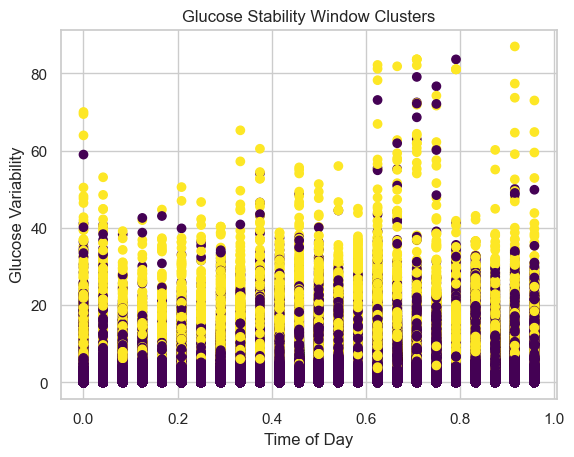

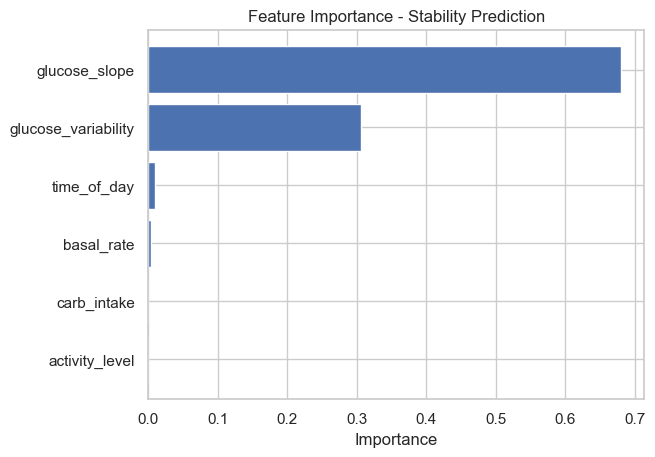

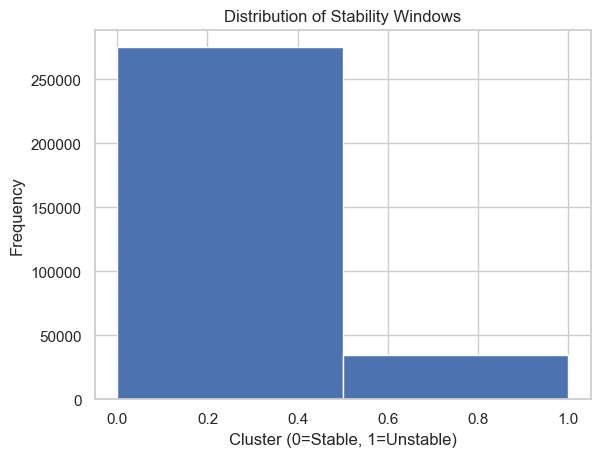

In [4]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. PREP DATA
df = df.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["patient_id", "time"])


# 2. FEATURE ENGINEERING
# Time of day
df["hour"] = df["time"].dt.hour
df["time_of_day"] = df["hour"] / 24.0

# Glucose variability (rolling std)
df["glucose_variability"] = (
    df.groupby("patient_id")["glucose"]
    .rolling(5)
    .std()
    .reset_index(level=0, drop=True)
)
df["glucose_variability"] = df["glucose_variability"].fillna(0)

# Glucose slope
df["glucose_slope"] = df.groupby("patient_id")["glucose"].diff().fillna(0)

# Safe fallback features
if "basal_rate" not in df.columns:
    df["basal_rate"] = 0
if "activity_level" not in df.columns:
    df["activity_level"] = 0
if "carb_intake" not in df.columns:
    df["carb_intake"] = 0

# 3. CLUSTERING (UNSUPERVISED)
cluster_features = [
    "time_of_day",
    "basal_rate",
    "glucose_variability",
    "glucose_slope"
]

X_cluster = df[cluster_features]
kmeans = KMeans(n_clusters=2, random_state=42)
df["stability_cluster"] = kmeans.fit_predict(X_cluster)

# Interpret clusters:
# lower variability cluster → stable window
# 4. SUPERVISED MODEL (PREDICTION)
features = [
    "time_of_day",
    "basal_rate",
    "glucose_variability",
    "glucose_slope",
    "activity_level",
    "carb_intake"
]
X = df[features]
y = df["stability_cluster"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


# 5. VISUALIZATION 1: STABILITY OVER TIME
plt.figure()
plt.scatter(df["time_of_day"], df["glucose_variability"], 
            c=df["stability_cluster"], cmap="viridis")
plt.title("Glucose Stability Window Clusters")
plt.xlabel("Time of Day")
plt.ylabel("Glucose Variability")
plt.show()

# 6. VISUALIZATION 2: FEATURE IMPORTANCE
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)
plt.figure()
plt.barh(importance["feature"], importance["importance"])
plt.title("Feature Importance - Stability Prediction")
plt.xlabel("Importance")
plt.show()

# 7. VISUALIZATION 3: STABILITY DISTRIBUTION
plt.figure()
plt.hist(df["stability_cluster"], bins=2)
plt.title("Distribution of Stability Windows")
plt.xlabel("Cluster (0=Stable, 1=Unstable)")
plt.ylabel("Frequency")
plt.show()

## HYPOGLYCEMIA EARLY WARNING PREDICTION HIGH-RISK EVENT DETECTION
 # Hypothesis
Hypoglycemia (<70 mg/dL) is not sudden—it is preceded by detectable patterns in glucose trend, insulin activity, and physical exertion. These patterns can be learned to predict risk 30–60 minutes in advance.

# Markers 
- Current glucose level
- Glucose slope (rapid decline indicator)
- Glucose volatility (rolling std)
- Insulin On Board (IOB)
- Activity level
- - Time of day (circadian risk factor)
Recent carb intake

# Model Approach
- Random Forest Classifier (baseline strong)
- XGBoost Classifier (best performance)
- Time-window labeling (important insight)



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57760
           1       1.00      1.00      1.00      4119

    accuracy                           1.00     61879
   macro avg       1.00      1.00      1.00     61879
weighted avg       1.00      1.00      1.00     61879



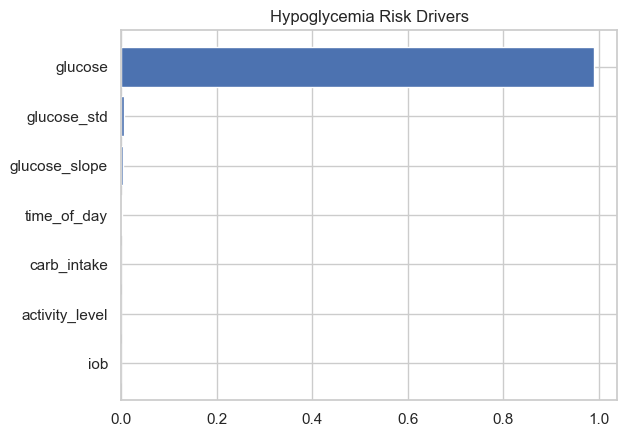

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = df.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["patient_id", "time"])

# FEATURE ENGINEERING
df["glucose_slope"] = df.groupby("patient_id")["glucose"].diff().fillna(0)
df["glucose_std"] = df.groupby("patient_id")["glucose"].rolling(5).std().reset_index(level=0, drop=True).fillna(0)

if "insulin_bolus" not in df.columns:
    df["insulin_bolus"] = 0

df["iob"] = df.groupby("patient_id")["insulin_bolus"].cumsum()

if "activity_level" not in df.columns:
    df["activity_level"] = 0

if "carb_intake" not in df.columns:
    df["carb_intake"] = 0

df["hour"] = df["time"].dt.hour
df["time_of_day"] = df["hour"] / 24.0

# TARGET LABEL (Hypoglycemia risk)
df["hypo_risk"] = (df["glucose"] < 70).astype(int)

# FEATURES
features = [
    "glucose",
    "glucose_slope",
    "glucose_std",
    "iob",
    "activity_level",
    "carb_intake",
    "time_of_day"
]

X = df[features]
y = df["hypo_risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

# VISUALIZATION
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=True)

plt.figure()
plt.barh(importance["feature"], importance["importance"])
plt.title("Hypoglycemia Risk Drivers")
plt.show()

## PERSONALIZED GLYCEMIC RESPONSE MEAL IMPACT MODEL PREDICTION

# Hypothesis

Every patient has a unique metabolic response curve to carbohydrates depending on insulin sensitivity, activity, and time of day.

So instead of predicting glucose, we predict:

How severe will glucose spike be after a meal?

# Markers
- Carb intake
- Pre-meal glucose
- Insulin dose
- Activity level
- Time of day
- Glucose slope before meal

# Model Approach
- Regression model (XGBoost / Random Forest)
- Window-based meal alignment 
- Predict peak glucose rise

MAE: 5.067788685402835


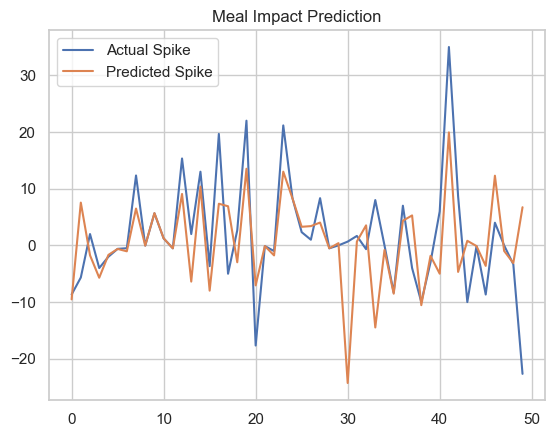

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

df = df.copy()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(["patient_id", "time"])

# FEATURES
df["glucose_slope"] = df.groupby("patient_id")["glucose"].diff().fillna(0)
if "carb_intake" not in df.columns:
    df["carb_intake"] = 0
if "insulin_bolus" not in df.columns:
    df["insulin_bolus"] = 0
if "activity_level" not in df.columns:
    df["activity_level"] = 0
df["hour"] = df["time"].dt.hour
df["time_of_day"] = df["hour"] / 24.0

# TARGET: glucose spike proxy
df["future_glucose"] = df.groupby("patient_id")["glucose"].shift(-3)
df["glucose_spike"] = df["future_glucose"] - df["glucose"]
df = df.dropna()

# MODEL FEATURES
features = [
    "glucose",
    "glucose_slope",
    "carb_intake",
    "insulin_bolus",
    "activity_level",
    "time_of_day"
]
X = df[features]
y = df["glucose_spike"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))

# VISUALIZATION
plt.figure()
plt.plot(y_test.values[:50], label="Actual Spike")
plt.plot(y_pred[:50], label="Predicted Spike")
plt.title("Meal Impact Prediction")
plt.legend()
plt.show()